In [1]:
!nvidia-smi

Thu Apr  9 14:46:27 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.161.07             Driver Version: 535.161.07   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100 80GB PCIe          On  | 00000000:E3:00.0 Off |                   On |
| N/A   41C    P0              63W / 300W |                  N/A |     N/A      Default |
|                                         |                      |              Enabled |
+-----------------------------------------+----------------------+--

In [2]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:
os.chdir('tracking_football/notebooks/yolov5/')
%pip install -r requirements.txt

  Using cached GitPython-3.1.43-py3-none-any.whl.metadata (13 kB)
  Using cached matplotlib-3.7.1-cp38-cp38-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.6 kB)
  Using cached numpy-1.24.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
  Using cached opencv_python-4.8.0.76-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
  Using cached pillow-10.3.0-cp38-cp38-manylinux_2_28_x86_64.whl.metadata (9.2 kB)
  Using cached psutil-5.9.5-cp36-abi3-manylinux_2_12_x86_64.manylinux2010_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (21 kB)
  Using cached PyYAML-6.0.1-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.1 kB)
  Using cached requests-2.31.0-py3-none-any.whl.metadata (4.6 kB)
ERROR: Ignored the following versions that require a different python version: 1.11.0 Requires-Python <3.13,>=3.9; 1.11.0rc1 Requires-Python <3.13,>=3.9; 1.11.0rc2 Requires-Python <3.13,>=3.9; 1.11.1 Requires-Python

In [4]:
import torch

In [5]:
from typing import Generator
import matplotlib.pyplot as plt
import numpy as np
import cv2

def generate_frames(video_file: str) -> Generator[np.ndarray, None, None]:
    video = cv2.VideoCapture(video_file)
    
    while video.isOpened():
        success, frame = video.read()
        
        if not success:
            break
        
        yield frame
    
    video.release()
    
def plot_image(image: np.ndarray, size: int = 12) -> None:
    plt.figure(figsize=(size, size))
    plt.imshow(image[...,::-1])
    plt.show()

In [25]:
video_path = "/home/elicer/projects/football-tracking/tracking_football/sample_videos/0a2d9b_6.mp4"
frame_iterator = iter(generate_frames(video_file=video_path))

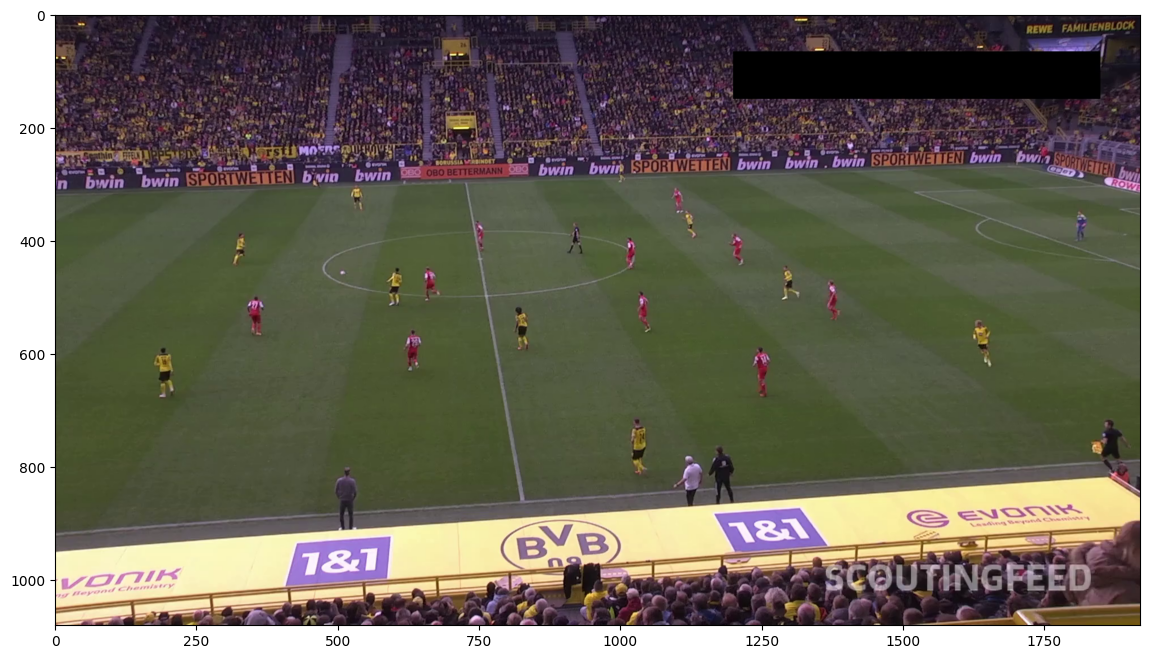

In [26]:
frame = next(frame_iterator)
plot_image(frame, 14)

In [27]:
import os
os.chdir('/home/elicer/projects/football-tracking/tracking_football/notebooks/yolov5')

In [29]:
!python detect.py --weights /home/elicer/projects/football-tracking/tracking_football/notebooks/yolov5/yolov5x.pt --img 1280 --conf 0.25 --source /home/elicer/projects/football-tracking/tracking_football/sample_videos/0a2d9b_6.mp4 --name coco_result

detect: weights=['/home/elicer/projects/football-tracking/tracking_football/notebooks/yolov5/yolov5x.pt'], source=/home/elicer/projects/football-tracking/tracking_football/sample_videos/0a2d9b_6.mp4, data=data/coco128.yaml, imgsz=[1280, 1280], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=coco_result, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
requirements: Ultralytics requirements ['gitpython==3.1.43', 'matplotlib==3.7.1', 'numpy==1.24', 'opencv-python==4.8.0.76', 'pillow==10.3.0', 'psutil==5.9.5', 'PyYAML==6.0.1', 'requests==2.31.0', 'scipy==1.11.4', 'tqdm==4.66.4', 'ultralytics==8.2.20', 'seaborn==0.12.1', 'setuptools==67.7.2', 'wheel==0.43.0'] not found, attempting AutoUpdate...
ERROR: Ignored the following vers

In [30]:
weights_path = "/home/elicer/projects/football-tracking/tracking_football/notebooks/yolov5/best.pt"
model = torch.hub.load('ultralytics/yolov5', 'custom', weights_path, device=0)

/home/elicer/miniconda3/envs/yolo/lib/python3.8/site-packages/torch/hub.py:294: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(
Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /home/elicer/.cache/torch/hub/master.zip


requirements: Ultralytics requirement ['urllib3>=2.6.0 ; python_version > "3.8"'] not found, attempting AutoUpdate...


ERROR: Exception:
Traceback (most recent call last):
  File "/home/elicer/miniconda3/envs/yolo/lib/python3.8/site-packages/pip/_vendor/packaging/markers.py", line 266, in __init__
    self._markers = _normalize_extra_values(_parse_marker(marker))
  File "/home/elicer/miniconda3/envs/yolo/lib/python3.8/site-packages/pip/_vendor/packaging/_parser.py", line 253, in parse_marker
    return _parse_full_marker(Tokenizer(source, rules=DEFAULT_RULES))
  File "/home/elicer/miniconda3/envs/yolo/lib/python3.8/site-packages/pip/_vendor/packaging/_parser.py", line 257, in _parse_full_marker
    retval = _parse_marker(tokenizer)
  File "/home/elicer/miniconda3/envs/yolo/lib/python3.8/site-packages/pip/_vendor/packaging/_parser.py", line 266, in _parse_marker
    expression = [_parse_marker_atom(tokenizer)]
  File "/home/elicer/miniconda3/envs/yolo/lib/python3.8/site-packages/pip/_vendor/packaging/_parser.py", line 291, in _parse_marker_atom
    marker = _parse_marker_item(tokenizer)
  File "/home/el

Retry 1/2 failed: Command 'pip install --no-cache-dir "urllib3>=2.6.0 ; python_version > "3.8"" ' returned non-zero exit status 2.
Retry 2/2 failed: Command 'pip install --no-cache-dir "urllib3>=2.6.0 ; python_version > "3.8"" ' returned non-zero exit status 2.
requirements: ❌ Command 'pip install --no-cache-dir "urllib3>=2.6.0 ; python_version > "3.8"" ' returned non-zero exit status 2.


ERROR: Exception:
Traceback (most recent call last):
  File "/home/elicer/miniconda3/envs/yolo/lib/python3.8/site-packages/pip/_vendor/packaging/markers.py", line 266, in __init__
    self._markers = _normalize_extra_values(_parse_marker(marker))
  File "/home/elicer/miniconda3/envs/yolo/lib/python3.8/site-packages/pip/_vendor/packaging/_parser.py", line 253, in parse_marker
    return _parse_full_marker(Tokenizer(source, rules=DEFAULT_RULES))
  File "/home/elicer/miniconda3/envs/yolo/lib/python3.8/site-packages/pip/_vendor/packaging/_parser.py", line 257, in _parse_full_marker
    retval = _parse_marker(tokenizer)
  File "/home/elicer/miniconda3/envs/yolo/lib/python3.8/site-packages/pip/_vendor/packaging/_parser.py", line 266, in _parse_marker
    expression = [_parse_marker_atom(tokenizer)]
  File "/home/elicer/miniconda3/envs/yolo/lib/python3.8/site-packages/pip/_vendor/packaging/_parser.py", line 291, in _parse_marker_atom
    marker = _parse_marker_item(tokenizer)
  File "/home/el

In [31]:
results = model(frame, size=1280)
results.pandas()

WARNING ⚠️ NMS time limit 0.550s exceeded


YOLOv5 <class 'models.common.Detections'> instance
image 1/1: 1080x1920 1 goalkeeper, 20 players, 4 referees
Speed: 14.4ms pre-process, 193.9ms inference, 572.6ms NMS per image at shape (1, 3, 768, 1280)

In [32]:
model.names

{0: 'ball', 1: 'goalkeeper', 2: 'player', 3: 'referee'}

In [33]:
!python /home/elicer/projects/football-tracking/tracking_football/notebooks/yolov5/detect.py --weights /home/elicer/projects/football-tracking/tracking_football/notebooks/yolov5/best.pt --img 1280 --conf 0.25 --source /home/elicer/projects/football-tracking/tracking_football/sample_videos/0a2d9b_6.mp4 --name custom_result

detect: weights=['/home/elicer/projects/football-tracking/tracking_football/notebooks/yolov5/best.pt'], source=/home/elicer/projects/football-tracking/tracking_football/sample_videos/0a2d9b_6.mp4, data=data/coco128.yaml, imgsz=[1280, 1280], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=custom_result, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
requirements: Ultralytics requirements ['gitpython==3.1.43', 'matplotlib==3.7.1', 'numpy==1.24', 'opencv-python==4.8.0.76', 'pillow==10.3.0', 'psutil==5.9.5', 'PyYAML==6.0.1', 'requests==2.31.0', 'scipy==1.11.4', 'tqdm==4.66.4', 'ultralytics==8.2.20', 'seaborn==0.12.1', 'setuptools==67.7.2', 'wheel==0.43.0'] not found, attempting AutoUpdate...
ERROR: Ignored the following versi

In [34]:
os.chdir('/home/elicer/projects/football-tracking/tracking_football/notebooks')

!cd ByteTrack && pip3 install -r requirements.txt
!cd ByteTrack && python3 setup.py develop
!pip install cython_bbox

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 677.8/677.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 8.2 MB/s eta 0:00:00
  Created wheel for onnx-simplifier: filename=onnx_simplifier-0.3.5-py3-none-any.whl size=12854 sha256=6565efe164a779b7c93d426161a19c0e76d93ff0875ad030e955fb92f0a6a89e
  Stored in directory: /home/elicer/.cache/pip/wheels/67/41/4b/ab44ea796416a698b22f1445154937a23e2b867211b25d16f5
Successfully built onnx-simplifier
running develop
/home/elicer/miniconda3/envs/yolo/lib/python3.8/site-packages/setuptools/command/develop.py:41: EasyInstallDeprecationWarning: easy_install command is deprecated.
!!

        **************************************************************

In [ ]:
import sys
sys.path.append(f'')

In [35]:
!pip install onemetric --quiet

In [1]:
from dataclasses import dataclass

# Makes an instance of a data class immutable so its properties cannot be changed.
@dataclass(frozen=True)
class BYTETrackerArgs:
    track_thresh: float = 0.25
    track_buffer: int = 30
    match_thresh: float = 0.8
    aspect_ratio_thresh: float = 3.0
    min_box_area: float = 1.0
    mot20: bool = False